<a href="https://www.kaggle.com/code/samaaloda/fracture-classes?scriptVersionId=230300785" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np 
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/bone-break-classification-image-dataset/README.dataset.txt
/kaggle/input/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/389382_jpg.rf.8cb98ee798766a2d3f6a76279ba5d0d9.jpg
/kaggle/input/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/avulsionlessertrochanter01jakpelvis15yo_jpg.rf.075c733923f27bd4611acf064a41a4e3.jpg
/kaggle/input/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/000002_png.rf.c3e00ebc2db78bc94e644c3f6605dad0.jpg
/kaggle/input/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/1b62e6fbfbc5a2f70c6af413189cfc82_jpg.rf.2761e933cc6d206308877cccaf0642b2.jpg
/kaggle/input/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification/Avulsion fracture/Test/13256_2019_2325_Fig

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from pathlib import Path
import cv2
import time
import random
from PIL import Image 
from keras import utils

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras import optimizers

from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Activation, Dropout, BatchNormalization ,Conv2D, MaxPooling2D, Flatten, Dense,Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score, precision_score, recall_score, f1_score


In [3]:
data_dir= '/kaggle/input/bone-break-classification-image-dataset/Bone Break Classification/Bone Break Classification'
train_data=utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40,
)

Found 1129 files belonging to 10 classes.
Using 904 files for training.


In [4]:
vald_data=utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40,
)

Found 1129 files belonging to 10 classes.
Using 225 files for validation.


In [5]:
classes=train_data.class_names
print(classes)

def normalize(image, label):
  return image/255.0, label

train_data = train_data.map(normalize)

vald_data= vald_data.map(normalize)

train_x=[]
train_y=[]
for image,label in train_data:
   train_x.append(image)
   train_y.append(label)
   print(type(train_y))
train_x = tf.concat(train_x, axis=0)
train_y = tf.concat(train_y, axis=0)

print(train_y)
type(train_y)

['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
<class 'list'>
tf.Tensor(
[4 2 2 4 8 4 1 4 1 9 2 3 2 0 7 6 0 6 5 9 5 0 3 5 4 7 2 5 1 2 9 8 2 7 4 4 4
 2 9 9 6 0 1 8 9 2 9 9 2 8 9 9 6 3 8 2 6 1 0 1 2 0 5 6 8 1 2 8 1 5 1 8 1 0
 5 3 3 8 9 9 2 0 3 3 2 8 3 3 5 3 2 2 6 1 2 5 1 3 2 8 9 2 5 8 4 2 9 5 0 3 4
 1 8 4 6 3 3 2 9 1 4 5 5 8 3 5 5 8 0 0 5 1 6 3 8 3 3 1 5 7 9 4 7 3 2 7 1 2
 6 1 5 3 2 1 8 9 2 7 4 1 1 2 2 3 3 6 2 4 4 0 1 8 7 0 4 3 8 4 6 3 3 3 1 4 6
 7 5 9 2 3 1 5 1 0 1 3 0 8 0 3 9 8 0 1 0 3 8 8 1 1 3 6 3 5 1 3 3 2 4 8 5 2
 0 5 2 8 2 7 5 5 0 3 7 0 3 5 9 5 3 9 7 6 2 6 6 5 0 9 1 1 2 9 1 3 9 2 8 2 3
 4 2 1 8 8 4 0 6

tensorflow.python.framework.ops.EagerTensor

In [6]:
train_data = utils.image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    shuffle=True,
    color_mode="rgb",
    image_size=(256,256),
    batch_size=64,
    seed=40
)

class_names = train_data.class_names
print("Class names:", class_names)

Found 1129 files belonging to 10 classes.
Using 904 files for training.
Class names: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


In [7]:
val_x=[]
val_y=[]
for image,label in train_data:
   val_x.append(image)
   val_y.append(label)
val_x = tf.concat(val_x, axis=0)
val_y = tf.concat(val_y, axis=0)

num_classes = 10
train_y = tf.keras.utils.to_categorical(train_y, num_classes=num_classes)
val_y = tf.keras.utils.to_categorical(val_y, num_classes=num_classes)

In [8]:
model = Sequential([
    Input(shape=(256, 256, 3)),  
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  
])

In [9]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
history = model.fit(train_x, train_y, batch_size=10, epochs=10,verbose = 1)
train_loss, train_accuracy = model.evaluate(train_x,train_y, verbose=0)
print(f"Training Accuracy: {train_accuracy}%")

test_loss, test_accuracy = model.evaluate(val_x,val_y, verbose=0)
print(f"Test Accuracy: {test_accuracy}%")
CLASSES = np.array(class_names)

preds = model.predict(val_x)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.1264 - loss: 3.3426
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.2284 - loss: 2.2411
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.4812 - loss: 1.6338
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7705 - loss: 0.8141
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.8883 - loss: 0.3760
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9533 - loss: 0.2761
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.9705 - loss: 0.1882
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9787 - loss: 0.1324
Epoch 9/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.9834 - loss: 0.2060
Epoch 10/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9890 - loss: 0.0630
Training Accuracy: 0.9944690465927124%
Test Accuracy: 0.9955752491950989%
29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step


In [11]:
print(dir(model))

['__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_add_trackable_child', '_add_variable_with_custom_getter', '_allow_non_tensor_positional_args', '_api_export_path', '_api_export_symbol_id', '_assert_compile_called', '_assert_input_compatibility', '_auto_config', '_build_by_run_for_kwargs', '_build_by_run_for_single_pos_arg', '_build_shapes_dict', '_call_has_mask_arg', '_call_has_training_arg', '_call_signature', '_called', '_check_quantize_args', '_check_super_called', '_checkpoint_adapter', '_checkpoint_dependencies', '_clear_losses', '_compile_config', '_compile_loss', '_compile_metrics', '_compiled_metrics_update_state', '_compute_loss', '_compute_loss_has_trai

In [12]:
preds_single = CLASSES[np.argmax(preds, axis=-1)]
actual_single = CLASSES[np.argmax(val_y, axis=-1)]
y_pred = model.predict(val_x)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(val_y, axis=1)

class_names = [
    'Avulsion fracture', 
    'Comminuted fracture', 
    'Fracture Dislocation',
    'Greenstick fracture',
    'Hairline Fracture',
    'Impacted fracture',
    'Longitudinal fracture',
    'Oblique fracture',
    'Pathological fracture',
    'Spiral Fracture'
]

report = classification_report(y_true_classes, y_pred_classes, target_names=class_names)
print(report)

29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step
                       precision    recall  f1-score   support

    Avulsion fracture       0.99      1.00      1.00       101
  Comminuted fracture       1.00      1.00      1.00       110
 Fracture Dislocation       1.00      1.00      1.00       135
  Greenstick fracture       0.99      1.00      1.00       101
    Hairline Fracture       1.00      1.00      1.00        87
    Impacted fracture       0.99      0.97      0.98        68
Longitudinal fracture       0.99      1.00      0.99        73
     Oblique fracture       1.00      1.00      1.00        67
Pathological fracture       1.00      1.00      1.00       102
      Spiral Fracture       1.00      0.97      0.98        60

             accuracy                           1.00       904
            macro avg       1.00      0.99      0.99       904
         weighted avg       1.00      1.00      1.00       904



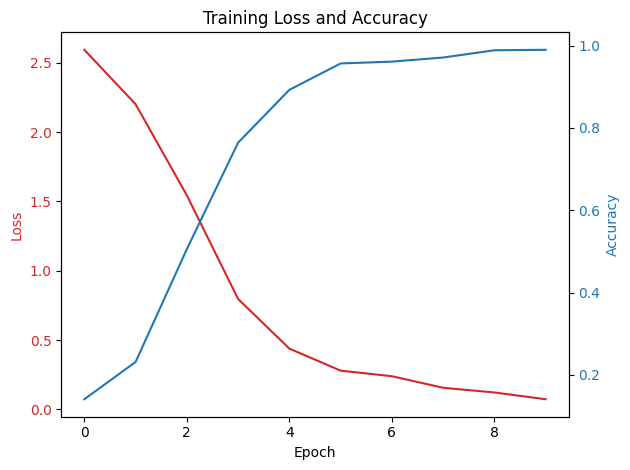

29/29 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9928 - loss: 10.8142
Test Accuracy: 99.56%


In [13]:
fig, ax1 = plt.subplots()

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(history.history['loss'], color='tab:red', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Accuracy', color='tab:blue')
ax2.plot(history.history['accuracy'], color='tab:blue', label='Train Accuracy')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Training Loss and Accuracy')
fig.tight_layout()
plt.show()


test_loss, test_accuracy = model.evaluate(val_x, val_y, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

In [14]:
model.save('/kaggle/working/fracture_classes.h5')

In [15]:
from tensorflow.keras.models import load_model
model = load_model('/kaggle/working/fracture_classes.h5')  

In [16]:
import numpy as np
import cv2
import tensorflow as tf

def preprocess_image(img_path):
    img = cv2.imread(img_path)  # Load image using OpenCV
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB
    img = cv2.resize(img, (256, 256))  # Resize image to match model input
    img = img / 255.0  # Normalize pixel values (0 to 1)
    img_array = np.expand_dims(img, axis=0)  # Add batch dimension
    return img_array

def predict_image(img_path, model, class_names):
    processed_img = preprocess_image(img_path)
    prediction = model.predict(processed_img)  # Get model predictions
    predicted_class = class_names[np.argmax(prediction)]  # Get class label
    confidence = np.max(prediction)  # Get confidence score
    return predicted_class, confidence

img_path = "/kaggle/input/tibial-fracture/x-ray-of-fracture-tibia.jpg"  # Replace with your image path
predicted_class, confidence = predict_image(img_path, model, class_names)
print(f"Predicted Class: {predicted_class}, Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Class: Oblique fracture, Confidence: 1.00
